We know this works on its own.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path("~/Documents/vggt2/digitizing_reality/TRELLIS.2").expanduser()))

In [2]:
import os
os.environ['OPENCV_IO_ENABLE_OPENEXR'] = '1'
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"  # Can save GPU memory
import cv2
import imageio
from PIL import Image
import torch
from trellis2.pipelines import Trellis2ImageTo3DPipeline
from trellis2.utils import render_utils
from trellis2.renderers import EnvMap
import o_voxel

# !pip install matplotlib
from matplotlib import pyplot as plt

/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[SPARSE] Conv backend: flex_gemm; Attention backend: flash_attn


In [3]:
# 1. Setup Environment Map
envmap = EnvMap(torch.tensor(
    cv2.cvtColor(cv2.imread('./TRELLIS.2/assets/hdri/studio.exr', cv2.IMREAD_UNCHANGED), cv2.COLOR_BGR2RGB),
    dtype=torch.float32, device='cuda'
))

# 2. Load Pipeline
pipeline = Trellis2ImageTo3DPipeline.from_pretrained("microsoft/TRELLIS.2-4B")
pipeline.cuda()

[ATTENTION] Using backend: flash_attn


/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [4]:
new_test_img = Image.open("./slides/IMG_9740.jpg").convert("RGB")

mesh = pipeline.run(
    new_test_img,
)[0]
mesh.simplify(16777216)

frames = render_utils.render_video(mesh, envmap=envmap, num_frames=10)

# save each frame
out_dir = Path(f"./slides/amodal_recon")
out_dir.mkdir(parents=True, exist_ok=True)

for i, frame in enumerate(frames["shaded"]):
    imageio.imwrite(out_dir / f"view_{i:02d}.png", frame)

Rendering:   0%|          | 0/10 [00:00<?, ?it/s]/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/utils3d/torch/nerf.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/ahc/miniconda3/envs/trellis2/lib/python3.10/site-packages/torch/nn/functional.py:5015: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
Rendering: 100%|██████████| 10/10 [00:04<00:00,  2.45it/s]


(np.float64(-0.5), np.float64(2159.5), np.float64(3839.5), np.float64(-0.5))

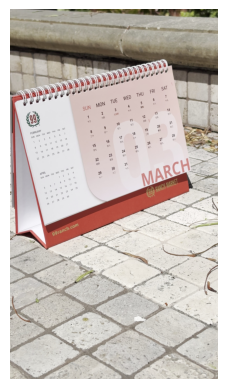

In [8]:
# 3. Load Image & Run
image = Image.open("./data/frame_A2.jpg")
plt.imshow(image)
plt.axis("off")

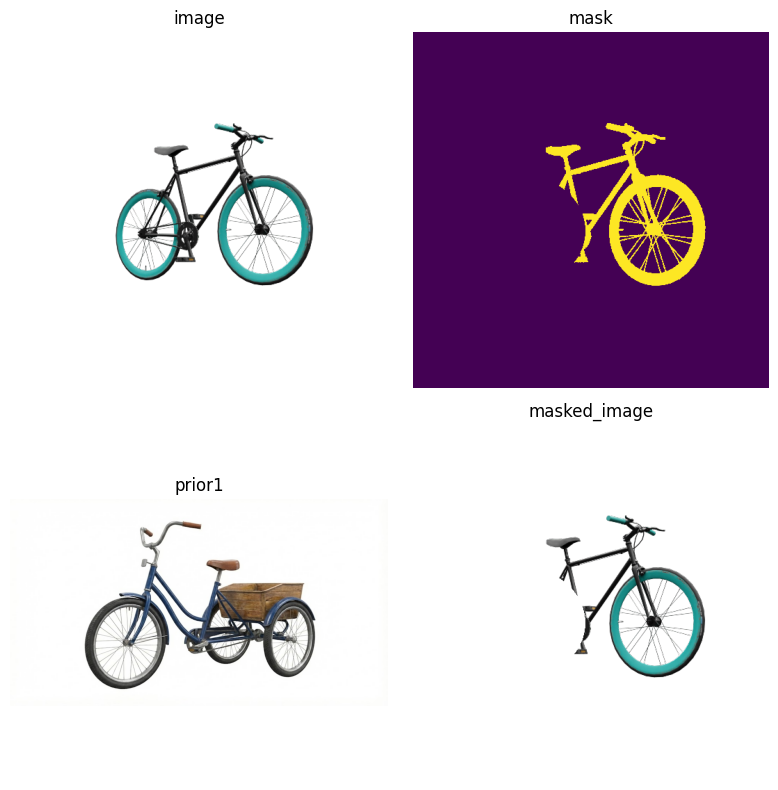

In [9]:
image = Image.open("./data/bike_three_wheels/input.png")
mask = Image.open("./data/bike_three_wheels/mask.png")
prior1 = Image.open("./data/bike_three_wheels/prior.jpg")

# image = Image.open("./data/A_bike_with_a_blue_front_wheel_and_a_red_rear_wheel/image.png")
# mask = Image.open("./data/A_bike_with_a_blue_front_wheel_and_a_red_rear_wheel/mask.png")
# prior1 = Image.open("./data/A_bike_with_a_blue_front_wheel_and_a_red_rear_wheel/prior.png")
masked_image = Image.composite(image, Image.new('RGBA', image.size, (0,0,0,0)), mask)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0, 0].axis("off")
axes[0, 0].imshow(image)
axes[0, 0].set_title("image")

axes[0, 1].axis("off")
axes[0, 1].imshow(mask)
axes[0, 1].set_title("mask")

axes[1, 0].axis("off")
axes[1, 0].imshow(prior1)
axes[1, 0].set_title("prior1")

axes[1, 1].axis("off")
axes[1, 1].imshow(masked_image)
axes[1, 1].set_title("masked_image")

plt.tight_layout()
plt.show()

In [10]:
mesh = pipeline.run(image)[0]
mesh.simplify(16777216) # nvdiffrast limit

# 4. Render Video
video = render_utils.make_pbr_vis_frames(render_utils.render_video(mesh, envmap=envmap))
imageio.mimsave("./data/eval/TRELLIS2.gif", video, fps=30, loop=0)

# # 5. Export to GLB
# glb = o_voxel.postprocess.to_glb(
#     vertices            =   mesh.vertices,
#     faces               =   mesh.faces,
#     attr_volume         =   mesh.attrs,
#     coords              =   mesh.coords,
#     attr_layout         =   mesh.layout,
#     voxel_size          =   mesh.voxel_size,
#     aabb                =   [[-0.5, -0.5, -0.5], [0.5, 0.5, 0.5]],
#     decimation_target   =   1000000,
#     texture_size        =   4096,
#     remesh              =   True,
#     remesh_band         =   1,
#     remesh_project      =   0,
#     verbose             =   True
# )
# glb.export("sample.glb", extension_webp=True)

Rendering: 100%|██████████| 120/120 [00:37<00:00,  3.21it/s]
